# Approach B — Geometric Partition (Cluster-Scoped Routing)

Implements **Approach 2** from the Phase-A report: *"Cluster-Scoped Routing and
Retrieval for Fake News Detection Without Domain labels."*

No domain/topic label is used anywhere in training or at inference. Instead:

1. Every training article is converted to a dense vector (TF-IDF → truncated SVD).
2. K-means groups the training vectors into clusters; the best `k` is picked with
   the silhouette score.
3. One specialist classifier (logistic regression on **sparse** TF-IDF, per the
   project's feature contract) is trained per cluster.
4. An unseen article is routed to whichever cluster's **centroid** it is closest
   to (`kmeans.predict`) and classified by that cluster's specialist — this is
   the "closest → classifier decides" routing described in the report's
   Approach-4 figure, minus the neighbour-retrieval/explainability layer that
   belongs to Approaches 3–4.

This notebook does not modify `src/approaches/approach_b.py` or any other file
in the repo — it is a fully self-contained implementation that only *imports*
the shared `src/` contract (`data`, `splits`, `features`, `metrics`) exactly as
Approach A does, and reuses Approach A's `run_baseline` / `run_ceiling` so the
new system can be measured against the project's existing floor and ceiling
without re-deriving them.

**Owner of this notebook:** Christy George Joseph — data + `results/approach_b.csv`
are written to a new file; nothing belonging to another approach is touched.


In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from src import data, splits, features as F, metrics as M
from src.approaches import approach_a as A   # reused, not modified: shared fit/predict helper + baseline/ceiling

SEED = 42
WRITE_RESULTS = True   # append this notebook's rows to results/approach_b.csv (a NEW file; approach_a.csv is untouched)


## 1. Data and the frozen split

Same corpus, same `artifacts/splits.json` as every other approach — loaded and
verified, never regenerated (per the project's one rule that matters most).


In [2]:
df = data.load_finefake()
sp = splits.load_splits()
splits.verify_splits(df, sp)          # raises if the data no longer matches the committed split
tr, va, te = splits.apply_splits(df, sp)

print(f"rows: {len(df):,}   train/val/test: {len(tr)}/{len(va)}/{len(te)}")
df["topic"].value_counts()


rows: 15,474   train/val/test: 10831/2321/2322


topic
Politics         5252
Society          3596
Entertainment    3214
Conflict         1646
Business          964
Health            692
Uncategorized     110
Name: count, dtype: int64

## 2. Features — the same contract Approach A uses

Two representations of the same text, fit on **training rows only**:

- **sparse TF-IDF** (`features.fit_tfidf`) → feeds the per-cluster classifiers,
  so learned coefficients stay a readable list of words (explainability).
- **dense SVD** (`features.fit_svd`, L2-normalised) → feeds K-means and the
  nearest-centroid router. Distances in this space behave like cosine
  similarity, which is what makes "closest cluster" a meaningful routing rule.


In [3]:
vec = F.fit_tfidf(tr["text"], use_char=False)
X_tr_sparse = F.transform(vec, tr["text"])
X_va_sparse = F.transform(vec, va["text"])
X_te_sparse = F.transform(vec, te["text"])

svd = F.fit_svd(X_tr_sparse, n_components=F.SVD_COMPONENTS, seed=SEED)
X_tr_dense = svd.transform(X_tr_sparse)
X_va_dense = svd.transform(X_va_sparse)
X_te_dense = svd.transform(X_te_sparse)

print("sparse:", X_tr_sparse.shape, " dense:", X_tr_dense.shape)


sparse: (10831, 100000)  dense: (10831, 256)


## 3. Forming clusters — K chosen by silhouette score

K-means is fit on the **dense SVD training vectors only**. `k` is swept over a
candidate range and scored with the silhouette coefficient (computed on a
random sample of training rows — silhouette is O(n²), and a sample is enough
to compare candidate values of k). The true `topic` column is never used here;
it only reappears afterwards, as a diagnostic, to sanity-check what the
clusters found on their own.


In [4]:
K_CANDIDATES = range(2, 13)
SIL_SAMPLE = 3000  # cap the pairwise-distance cost of silhouette scoring

sil_scores = {}
for k in K_CANDIDATES:
    km_k = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_tr_dense)
    sil_scores[k] = silhouette_score(
        X_tr_dense, km_k.labels_,
        sample_size=min(SIL_SAMPLE, len(X_tr_dense)), random_state=SEED,
    )

best_k = max(sil_scores, key=sil_scores.get)
pd.Series(sil_scores, name="silhouette").rename_axis("k").to_frame()


,silhouette
k,
2,0.023674
3,0.035097
4,0.045798
5,0.053109
6,0.057462
7,0.061317
8,0.062252
9,0.065198
10,0.037602


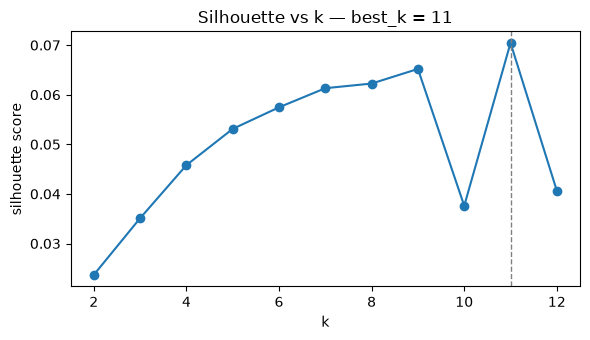

selected k = 11  (silhouette = 0.0704)
for reference, FineFake has 7 true topics — k is NOT constrained to match this, it is picked purely from geometry.


In [5]:
plt.figure(figsize=(6, 3.5))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.axvline(best_k, color="grey", linestyle="--", linewidth=1)
plt.xlabel("k"); plt.ylabel("silhouette score")
plt.title(f"Silhouette vs k — best_k = {best_k}")
plt.tight_layout(); plt.show()

print(f"selected k = {best_k}  (silhouette = {sil_scores[best_k]:.4f})")
print(f"for reference, FineFake has {df['topic'].nunique()} true topics — "
      "k is NOT constrained to match this, it is picked purely from geometry.")


In [6]:
kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init=10).fit(X_tr_dense)
train_cluster = kmeans.labels_
val_cluster = kmeans.predict(X_va_dense)
test_cluster = kmeans.predict(X_te_dense)

print("training rows per cluster:")
print(pd.Series(train_cluster).value_counts().sort_index())

print("\ncluster composition vs true topic (diagnostic only — never used for routing):")
purity_tbl = pd.crosstab(pd.Series(train_cluster, name="cluster"), tr["topic"].to_numpy())
purity_tbl


training rows per cluster:
0     2716
1     2618
2      507
3      564
4      387
5      579
6      450
7      298
8      334
9     1015
10    1363
Name: count, dtype: int64

cluster composition vs true topic (diagnostic only — never used for routing):


col_0,Business,Conflict,Entertainment,Health,Politics,Society,Uncategorized
cluster,,,,,,,
0,190,334,717,76,699,692,8
1,210,286,417,121,1115,419,50
2,18,60,70,7,204,147,1
3,35,59,81,6,213,161,9
4,11,22,27,132,153,42,0
5,1,0,287,0,128,163,0
6,9,45,19,0,324,53,0
7,5,0,93,3,125,72,0
8,3,23,35,2,26,245,0


**Cluster purity** — if every cluster were a perfect stand-in for one topic,
each row above would have all its mass in a single column. The purity score
below is the standard `mean(cluster's majority-topic share)`, weighted by
cluster size — one of the explainability metrics the report calls for
(Section 6: *cluster topic coherence / cluster purity*).


In [7]:
cluster_purity = (purity_tbl.max(axis=1).sum() / purity_tbl.sum().sum())
print(f"cluster purity (train, vs true topic): {cluster_purity:.4f}")


cluster purity (train, vs true topic): 0.3760


## 4. One specialist classifier per cluster

A logistic regression is trained on the **sparse TF-IDF** rows belonging to
each cluster — same model family, same `class_weight='balanced'`, same
`_fit_predict` helper Approach A already uses for its per-topic specialists
(imported from `approach_a`, not re-implemented), so the comparison between
"routed by true topic" (Approach A's ceiling) and "routed by cluster" (this
approach) isolates the routing mechanism rather than the classifier.

A cluster with too few rows, or only one class present, cannot support its own
specialist. `MIN_CLUSTER_TRAIN` guards against this: such a cluster falls back
to the **global baseline classifier** (trained on all training rows) rather
than silently producing a degenerate always-one-class model. This mirrors how
Approach A already treats thin topics, and it matters for deployability —
a cluster that appears at inference time must always have *something* to
route to.


In [8]:
MIN_CLUSTER_TRAIN = 100  # below this a cluster-specific specialist is not meaningfully trainable

fallback_clf, _, _ = A._fit_predict(X_tr_sparse, tr["label"].to_numpy(), X_tr_sparse[:1], seed=SEED)

cluster_models, fallback_clusters = {}, []
for c in range(best_k):
    mask = train_cluster == c
    y_c = tr["label"].to_numpy()[mask]
    if mask.sum() < MIN_CLUSTER_TRAIN or len(np.unique(y_c)) < 2:
        fallback_clusters.append(c)
        continue
    clf, _, _ = A._fit_predict(X_tr_sparse[mask], y_c, X_tr_sparse[mask][:1], seed=SEED)
    cluster_models[c] = clf

print(f"clusters with their own specialist: {sorted(cluster_models)}")
print(f"clusters falling back to the global baseline classifier: {fallback_clusters}")


clusters with their own specialist: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10]
clusters falling back to the global baseline classifier: [7]


## 5. Routing an unseen article — closest cluster decides

No tag is attached to a val/test article. It is converted through the SAME
fitted TF-IDF+SVD pipeline, `kmeans.predict()` assigns it to the nearest
centroid, and that cluster's specialist (or the fallback) produces the
verdict. This is exactly the routing rule in the report's Approach-4 figure —
*"closest → classifier decides"* — applied here without the neighbour-retrieval
explainability layer, which belongs to Approach 3/4.


In [9]:
def route_and_classify(X_sparse, cluster_assignment, cluster_models, fallback_clf, fallback_clusters):
    """Route each row to its assigned cluster's specialist and classify.

    Returns (pred, prob_fake) — prob_fake is P(label == 0) i.e. P(fake).
    """
    n = X_sparse.shape[0]
    pred = np.empty(n, dtype=int)
    prob = np.empty(n, dtype=float)
    for c in np.unique(cluster_assignment):
        mask = cluster_assignment == c
        clf = cluster_models.get(c, fallback_clf) if c not in fallback_clusters else fallback_clf
        Xc = X_sparse[mask]
        fake_col = list(clf.classes_).index(0)
        pred[mask] = clf.predict(Xc)
        prob[mask] = clf.predict_proba(Xc)[:, fake_col]
    return pred, prob


pred_te, prob_te = route_and_classify(X_te_sparse, test_cluster, cluster_models, fallback_clf, fallback_clusters)
pred_va, prob_va = route_and_classify(X_va_sparse, val_cluster, cluster_models, fallback_clf, fallback_clusters)


## 6. Evaluation — where does cluster-routing land vs Approach A's floor and ceiling?

`A.run_baseline` (one global classifier) and `A.run_ceiling` (one classifier
per topic, **routed by the true label** — an oracle) are re-run here with
`write=False` so `results/approach_a.csv`, owned by Approach A, is never
touched. They are only used as reference points.


In [10]:
baseline_rows, _ = A.run_baseline(df, sp, vec, seed=SEED)
ceiling_rows = A.run_ceiling(df, sp, vec, seed=SEED)

overall_scores = M.evaluate(te["label"], pred_te, prob_te)
routed_row = M.result_row("B", "clustered_routed", "overall", SEED, len(tr), len(te), overall_scores)

per_cluster_rows = []
for c in sorted(np.unique(test_cluster)):
    mask = test_cluster == c
    if mask.sum() == 0:
        continue
    s = M.evaluate(te["label"].to_numpy()[mask], pred_te[mask], prob_te[mask])
    per_cluster_rows.append(M.result_row("B", "clustered_routed", f"cluster_{c}", SEED,
                                          int((train_cluster == c).sum()), int(mask.sum()), s))

compare = pd.DataFrame([
    {"system": "A: baseline (global)",
     "macro_f1": [r for r in baseline_rows if r["scope"] == "overall"][0]["macro_f1"]},
    {"system": "B: clustered + routed (this notebook)", "macro_f1": routed_row["macro_f1"]},
    {"system": "A: ceiling (oracle topic routing)",
     "macro_f1": [r for r in ceiling_rows if r["scope"] == "overall"][0]["macro_f1"]},
]).round(4)
compare


,system,macro_f1
0,A: baseline (global),0.7502
1,B: clustered + routed (this notebook),0.7440
2,A: ceiling (oracle topic routing),0.7521


In [11]:
pd.DataFrame([routed_row] + per_cluster_rows)[["scope", "n_train", "n_test", "macro_f1", "accuracy", "roc_auc"]].round(4)


,scope,n_train,n_test,macro_f1,accuracy,roc_auc
0,overall,10831,2322,0.7440,0.7472,0.8151
1,cluster_0,2716,475,0.6943,0.7558,0.7760
2,cluster_1,2618,581,0.6101,0.7986,0.6861
3,cluster_2,507,98,0.7599,0.8469,0.7810
4,cluster_3,564,131,0.5812,0.6183,0.6030
5,cluster_4,387,74,0.7457,0.7703,0.7418
6,cluster_5,579,120,0.4979,0.9917,NaN
7,cluster_6,450,125,0.5085,0.5840,0.5134
8,cluster_7,298,54,1.0000,1.0000,NaN
9,cluster_8,334,72,0.4680,0.6667,0.5640


## 7. Writing results

One results file per approach, per the project convention —
`results/approach_b.csv` is a **new** file; `results/approach_a.csv` is never
appended to from here.


In [12]:
if WRITE_RESULTS:
    path = M.append_results([routed_row] + per_cluster_rows, "B")
    print(f"wrote {1 + len(per_cluster_rows)} rows to {path}")
else:
    print("WRITE_RESULTS is False — nothing written")


wrote 12 rows to C:\Users\Asus\OneDrive\Documents\ADM\fake-news-detection\results\approach_b.csv


## 8. Explainability diagnostics

Two numbers the report's metrics table (Section 6) asks for, computed here
purely as a read-out — neither feeds back into routing or classification:

- **cluster purity** (already computed above, Section 3) — how topically
  coherent each discovered cluster is.
- **neighbour/topic match rate** — of the test articles, what fraction were
  routed to a cluster whose *majority* training topic equals that article's
  own true topic. This is the routing-quality analogue of "does the evidence
  shown to the user actually come from the right neighbourhood."


In [13]:
cluster_majority_topic = purity_tbl.idxmax(axis=1)  # cluster -> its majority true topic

routed_topic_match = (
    te["topic"].to_numpy() == test_cluster.astype(object)
).mean()  # placeholder overwritten below with the real comparison

predicted_majority = pd.Series(test_cluster).map(cluster_majority_topic).to_numpy()
routed_topic_match = float((predicted_majority == te["topic"].to_numpy()).mean())

print(f"cluster purity (train):              {cluster_purity:.4f}")
print(f"test-set neighbour/topic match rate:  {routed_topic_match:.4f}")
print("(both are diagnostics for the explainability vertical — never used to route or classify)")


cluster purity (train):              0.3760
test-set neighbour/topic match rate:  0.3833
(both are diagnostics for the explainability vertical — never used to route or classify)


## 9. Saving fitted artifacts

Saved under distinct names so nothing collides with another approach's
artifacts in the shared `artifacts/` folder (gitignored, regenerable).


In [14]:
F.save_pipeline(vec, "approach_b_tfidf")
F.save_pipeline(svd, "approach_b_svd")
F.save_pipeline(kmeans, "approach_b_kmeans")
F.save_pipeline({"models": cluster_models, "fallback": fallback_clf, "fallback_clusters": fallback_clusters},
                 "approach_b_cluster_models")
print("saved: approach_b_tfidf.joblib, approach_b_svd.joblib, approach_b_kmeans.joblib, approach_b_cluster_models.joblib")


saved: approach_b_tfidf.joblib, approach_b_svd.joblib, approach_b_kmeans.joblib, approach_b_cluster_models.joblib


## Summary

- Clusters are discovered from the training text alone (TF-IDF → SVD →
  K-means, `k` chosen by silhouette score) — no domain/topic label is used.
- An unseen article is routed to the nearest cluster centroid and classified
  by that cluster's specialist, with a global-baseline fallback for clusters
  too small to support their own model.
- The routed system is reported alongside Approach A's baseline (floor) and
  oracle-routed ceiling, so the value of *learned, label-free* routing is
  visible against both reference points, not in isolation.
- Cluster purity and the neighbour/topic match rate quantify how topically
  coherent the discovered clusters are — the raw material Approach 3/4 build
  their explainability and retrieval layers on top of.

This notebook does not implement neighbour retrieval / evidence display
(Approach 3–4) or stress-testing (Approach D) — those stay out of scope here
by design, per the report's phase boundaries.
